In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction, CatalyticMichaelisMenten

import sys
sys.path.append('../../..')
from apps.habituation.hallmarks_helpers import compute_habituation_time, rectangular_pulse_program, compute_recovery_time, render_habituation
from apps.habituation.hallmarks import hallmark1_loss, hallmark2_loss, hallmark3_loss, hallmark4_loss, hallmark5_loss, hallmark6_loss, habituation_hallmarks_loss

## Parameter Values

In [2]:
CIFF_Parameters = {
    'kIa1': 0.023, 'kIi1': 34.44,
    'kMa1': 17.7071, 'kMi1': 0.038241,
    'kRa1': 57.9236, 'kRi1': 1.39117, 'K1': 0.000534,
    'kIa2': 0.016011, 'kIi2': 14.3342,
    'kMa2': 4.33609, 'kMi2': 0.001471,
    'kRa2': 26.1702, 'kRi2': 45.9986, 'K2': 0.79082,
}

## Build CIFF I/O CRN

In [3]:
p = dict(CIFF_Parameters)

reactions = [
    # First incoherent feed-forward motif.
    MassAction(['I1_i'], ['I1_a'], input_channels=['S'],
               params=[p['kIa1']], params_controllability=[False]),
    MassAction(['I1_a'], ['I1_i'], input_channels=[None],
               params=[p['kIi1']], params_controllability=[False]),
    MassAction(['I1_a', 'M1_i'], ['I1_a', 'M1_a'], input_channels=[None],
               params=[p['kMa1']], params_controllability=[False]),
    MassAction(['M1_a'], ['M1_i'], input_channels=[None],
               params=[p['kMi1']], params_controllability=[False]),
    MassAction(['I1_a', 'R1_i'], ['I1_a', 'R1_a'], input_channels=[None],
               params=[p['kRa1']], params_controllability=[False]),
    CatalyticMichaelisMenten(['R1_a'], ['R1_i'], ['M1_a'],
                              params=[p['kRi1'], p['K1']],
                              params_controllability=[False, False]),

    # Second motif, driven by active R1.
    MassAction(['R1_a', 'I2_i'], ['R1_a', 'I2_a'], input_channels=[None],
               params=[p['kIa2']], params_controllability=[False]),
    MassAction(['I2_a'], ['I2_i'], input_channels=[None],
               params=[p['kIi2']], params_controllability=[False]),
    MassAction(['I2_a', 'M2_i'], ['I2_a', 'M2_a'], input_channels=[None],
               params=[p['kMa2']], params_controllability=[False]),
    MassAction(['M2_a'], ['M2_i'], input_channels=[None],
               params=[p['kMi2']], params_controllability=[False]),
    MassAction(['I2_a', 'R2_i'], ['I2_a', 'R2_a'], input_channels=[None],
               params=[p['kRa2']], params_controllability=[False]),
    CatalyticMichaelisMenten(['R2_a'], ['R2_i'], ['M2_a'],
                              params=[p['kRi2'], p['K2']],
                              params_controllability=[False, False]),
]

ciff = IOCRN(reactions, output_labels=['R2_a'], solver='LSODA', atol=1e-9, rtol=1e-7)
ciff.compile()
print(ciff)

Inputs: ['S'] 
Species: ['I1_a', 'I1_i', 'I2_a', 'I2_i', 'M1_a', 'M1_i', 'M2_a', 'M2_i', 'R1_a', 'R1_i', 'R2_a', 'R2_i'] 
Output Species: ['R2_a'] 
I1_i ----> I1_a;  [MAK(0.023, S)]
I1_a ----> I1_i;  [MAK(34.44)]
I1_a + M1_i ----> I1_a + M1_a;  [MAK(17.7071)]
M1_a ----> M1_i;  [MAK(0.038241)]
I1_a + R1_i ----> I1_a + R1_a;  [MAK(57.9236)]
R1_a ----> R1_i;  [CatalyticMM(E=M1_a, k=1.39117, K=0.000534)]
I2_i + R1_a ----> I2_a + R1_a;  [MAK(0.016011)]
I2_a ----> I2_i;  [MAK(14.3342)]
I2_a + M2_i ----> I2_a + M2_a;  [MAK(4.33609)]
M2_a ----> M2_i;  [MAK(0.001471)]
I2_a + R2_i ----> I2_a + R2_a;  [MAK(26.1702)]
R2_a ----> R2_i;  [CatalyticMM(E=M2_a, k=45.9986, K=0.79082)]


## Initial Conditions

In [4]:
def inactive_initial_condition(crn):
    x0 = np.zeros(crn.num_species)
    for label in ['I1_i', 'M1_i', 'R1_i', 'I2_i', 'M2_i', 'R2_i']:
        x0[crn.species_label_to_idx(label)] = 1.0
    return x0

x0 = inactive_initial_condition(ciff)
print(x0)

[0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.]


## Stimulus Parameters

In [5]:
A, T, Ton, n_pulses = 10.0, 15, 1.11, 50

## Hallmark 1

In [6]:
h1_loss, h1_info = hallmark1_loss(ciff, A, T, Ton, n_pulses, x0, tolerance=0.01, eps=1e-12, LARGE_NUMBER=1e4, return_info=True)
print(f'Hallmark 1 loss: {h1_loss}')
print(h1_info)


Hallmark 1 loss: 0.024768405538405643
{'habituation_time': 14, 'time': array([0.00000000e+00, 9.91071429e-03, 1.98214286e-02, ...,
       7.49980000e+02, 7.49990000e+02, 7.50000000e+02], shape=(75150,)), 'input_signal': array([10., 10., 10., ...,  0.,  0.,  0.], shape=(75150,)), 'response': array([0.00000000e+00, 2.03827760e-09, 2.97003409e-08, ...,
       2.20381159e-08, 2.18564516e-08, 2.16762998e-08], shape=(75150,)), 'peaks': array([0.01008634, 0.00705904, 0.00412134, 0.00308221, 0.0026815 ,
       0.00248988, 0.0023837 , 0.00231731, 0.00227098, 0.0022353 ,
       0.00220575, 0.00217981, 0.0021565 , 0.00213492, 0.00211464,
       0.00209556, 0.00207747, 0.00206014, 0.00204351, 0.00202771,
       0.00201251, 0.00199784, 0.00198368, 0.00197011, 0.00195706,
       0.00194444, 0.00193221, 0.00192037, 0.00190898, 0.00189802,
       0.0018874 , 0.00187709, 0.00186709, 0.00185739, 0.00184802,
       0.00183901, 0.00183026, 0.00182177, 0.00181351, 0.0018055 ,
       0.00179771, 0.00179014,

## Visualize Hallmark 1

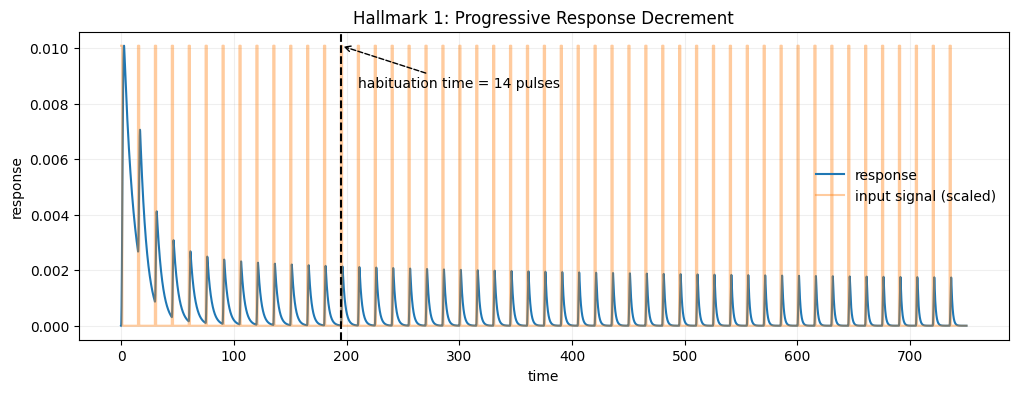

In [7]:
t = h1_info['time']
response = h1_info['response']
input_signal = h1_info['input_signal']
habituation_time = h1_info['habituation_time']
habituation_time_abs = (habituation_time - 1) * T

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, response, label='response', color='C0')

scaled_input = input_signal / max(np.max(input_signal), 1e-12) * max(np.max(response), 1e-12)
ax.step(t, scaled_input, where='post', label='input signal (scaled)', color='C1', alpha=0.4)

ax.axvline(habituation_time_abs, color='black', linestyle='--', linewidth=1.5)
ax.annotate(
    f'habituation time = {habituation_time} pulses',
    xy=(habituation_time_abs, np.max(response)),
    xytext=(habituation_time_abs + T, 0.85 * np.max(response)),
    arrowprops=dict(arrowstyle='->', linestyle='--', color='black'),
    ha='left',
)

ax.set_xlabel('time')
ax.set_ylabel('response')
ax.set_title('Hallmark 1: Progressive Response Decrement')
ax.grid(alpha=0.2)
ax.legend(frameon=False)
plt.show()


## Hallmark 2

In [8]:
h2_loss, h2_info = hallmark2_loss(ciff, A, T, Ton, h1_info['habituation_time'], x0, recovery_tolerance=0.05, max_gap=4000.0, search_depth=16, return_info=True)
print(f'Hallmark 2 loss: {h2_loss}')
print(h2_info)

Hallmark 2 loss: 0.389617919921875
{'recovery_time': 1558.4716796875, 'time': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, ...,
       1.78331168e+03, 1.78332168e+03, 1.78333168e+03], shape=(22519,)), 'input_signal': array([10., 10., 10., ...,  0.,  0.,  0.], shape=(22519,)), 'response': array([0.00000000e+00, 2.11091875e-09, 3.07339709e-08, ...,
       1.54339762e-03, 1.54111488e-03, 1.53883555e-03], shape=(22519,)), 'trajectory': array([[ 0.00000000e+00,  1.94363992e-03,  3.31782842e-03, ...,
        -8.14298715e-27, -9.20828273e-27, -1.03382979e-26],
       [ 1.00000000e+00,  9.98056360e-01,  9.96682172e-01, ...,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00],
       [ 0.00000000e+00,  3.14996653e-08,  2.23933209e-07, ...,
         3.28511769e-12,  3.21587207e-12,  3.14308173e-12],
       ...,
       [ 1.00000000e+00,  9.99405133e-01,  9.97864448e-01, ...,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00],
       [ 0.00000000e+00,  2.11091875e-09,  3.0

## Visualize Hallmark 2

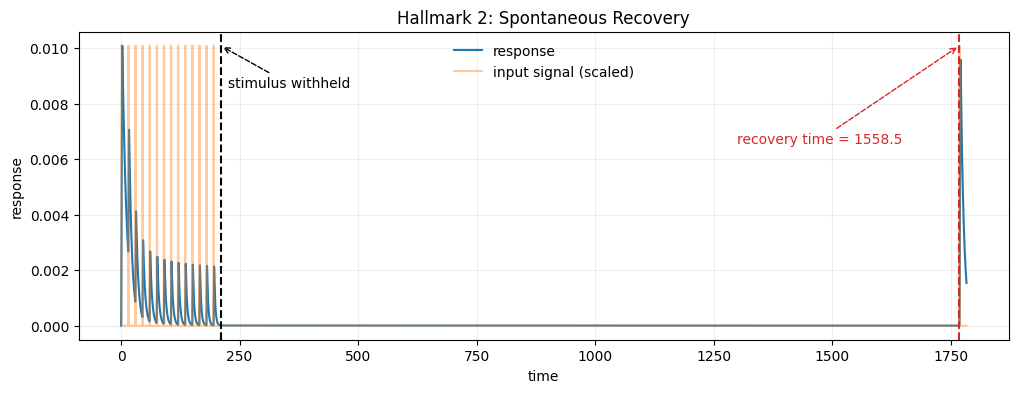

In [9]:
t = h2_info['time']
response = h2_info['response']
input_signal = h2_info['input_signal']
recovery_time = h2_info['recovery_time']
training_end = h1_info['habituation_time'] * T - 0.01
recovery_end = training_end + recovery_time

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, response, label='response', color='C0')

scaled_input = input_signal / max(np.max(input_signal), 1e-12) * max(np.max(response), 1e-12)
ax.step(t, scaled_input, where='post', label='input signal (scaled)', color='C1', alpha=0.4)

ax.axvline(training_end, color='black', linestyle='--', linewidth=1.5)
ax.axvline(recovery_end, color='C3', linestyle='--', linewidth=1.5)
ax.annotate('stimulus withheld', xy=(training_end, np.max(response)),
            xytext=(training_end + T, 0.85 * np.max(response)),
            arrowprops=dict(arrowstyle='->', linestyle='--', color='black'),
            ha='left')
ax.annotate(f'recovery time = {recovery_time:.1f}', xy=(recovery_end, np.max(response)),
            xytext=(recovery_end - 8 * T, 0.65 * np.max(response)),
            arrowprops=dict(arrowstyle='->', linestyle='--', color='C3'),
            ha='right', color='C3')

ax.set_xlabel('time')
ax.set_ylabel('response')
ax.set_title('Hallmark 2: Spontaneous Recovery')
ax.grid(alpha=0.2)
ax.legend(frameon=False)
plt.show()


## Hallmark 3

In [10]:
h3_loss, h3_info = hallmark3_loss(
    ciff, A, T, Ton, h1_info['habituation_time'], h2_info['recovery_time'], x0,
    n_series=2,
    recovery_gap_fraction=0.5,
    tolerance=0.01,
    return_info=True,
)
print(f'Hallmark 3 loss: {h3_loss}')
print({
    'habituation_times': h3_info['habituation_times'],
    'n_pulses': h3_info['n_pulses'],
    'recovery_gap': h3_info['recovery_gap'],
})


Hallmark 3 loss: 0.0
{'habituation_times': array([14., 10.]), 'n_pulses': 14, 'recovery_gap': 779.23583984375}


## Visualize Hallmark 3

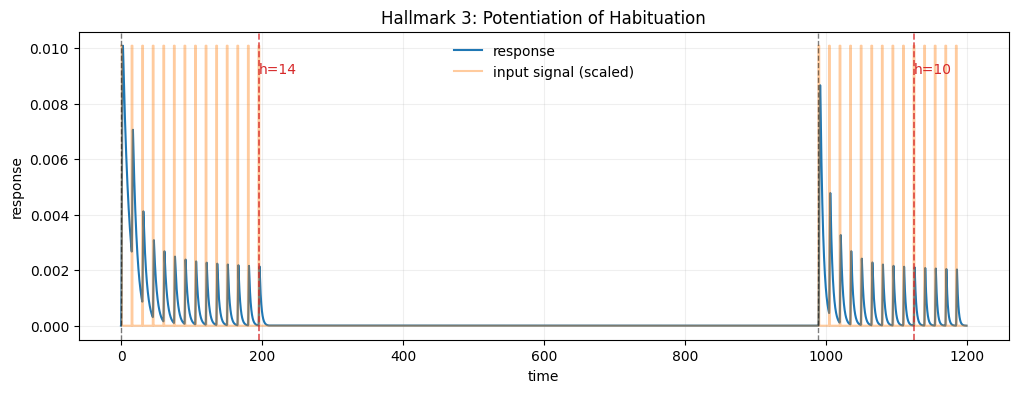

In [11]:
t = h3_info['time']
response = h3_info['response']
input_signal = h3_info['input_signal']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, response, label='response', color='C0')

scaled_input = input_signal / max(np.max(input_signal), 1e-12) * max(np.max(response), 1e-12)
ax.step(t, scaled_input, where='post', label='input signal (scaled)', color='C1', alpha=0.4)

series_period = h3_info['n_pulses'] * T + h3_info['recovery_gap']
for series_idx, ht in enumerate(h3_info['habituation_times']):
    series_start = series_idx * series_period
    ax.axvline(series_start, color='black', linestyle='--', linewidth=1.0, alpha=0.5)
    ht_time = series_start + (ht - 1) * T
    ax.axvline(ht_time, color='C3', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.text(ht_time, 0.9 * np.max(response), f'h={int(ht)}', color='C3', ha='left')

ax.set_xlabel('time')
ax.set_ylabel('response')
ax.set_title('Hallmark 3: Potentiation of Habituation')
ax.grid(alpha=0.2)
ax.legend(frameon=False)
plt.show()


## Hallmark 4

In [12]:
T_values = [15.0, 20.0, 25.0]
h4_loss, h4_info = hallmark4_loss(
    ciff, A, T_values, Ton, n_pulses, x0,
    tolerance=0.01,
    return_info=True,
)

print(f'Hallmark 4 frequency term: {h4_loss}')
pd.DataFrame({
    'T': h4_info['T_values'],
    'frequency': h4_info['frequencies'],
    'habituation_time': h4_info['habituation_times'],
})


Hallmark 4 frequency term: 0.7581818181818182


,T,frequency,habituation_time
0,15.0,0.066667,14.0
1,20.0,0.050000,22.0
2,25.0,0.040000,25.0


## Visualize Hallmark 4

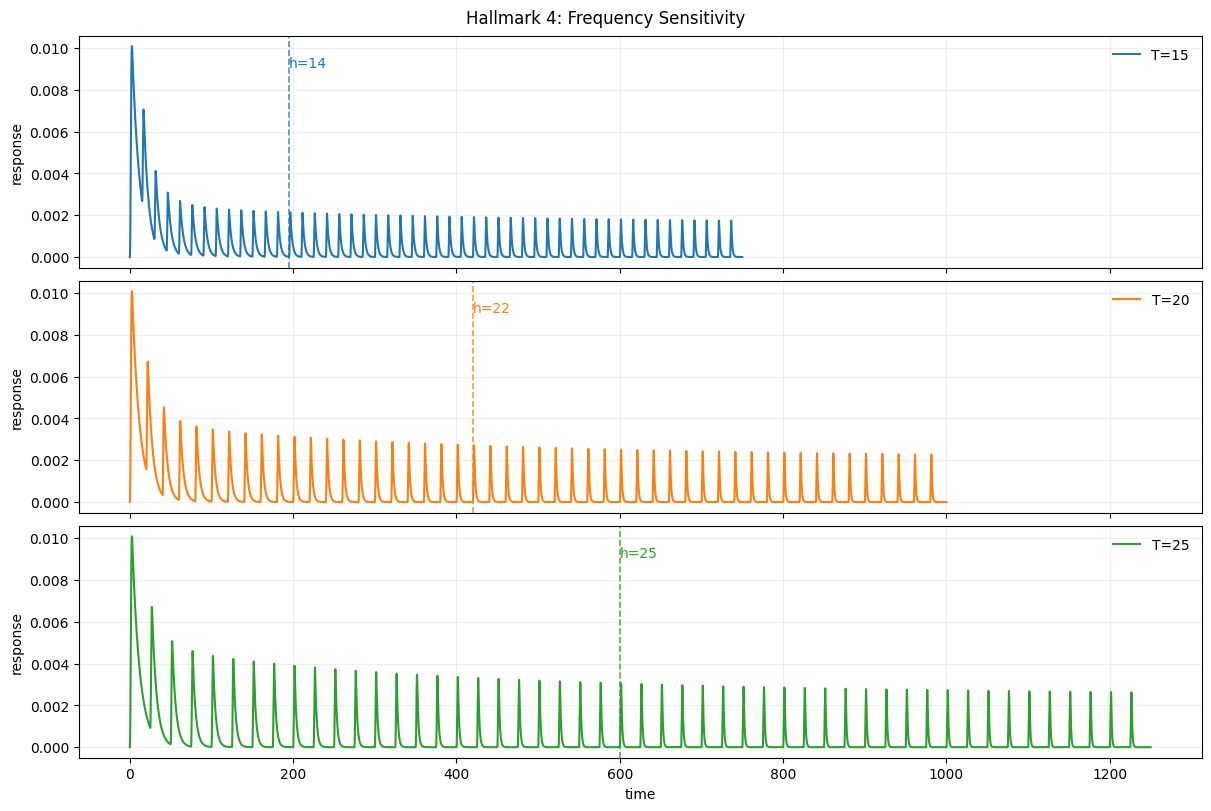

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for idx, (ax, run) in enumerate(zip(axes, h4_info['runs'])):
    color = colors[idx % len(colors)]
    T_run = run['T']
    h_run = h4_info['habituation_times'][idx]
    t = run['time']
    response = run['response']
    ht_time = (h_run - 1) * T_run

    ax.plot(t, response, color=color, label=f'T={T_run:g}')
    ax.axvline(ht_time, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
    ax.text(ht_time, 0.9 * np.max(response), f'h={int(h_run)}', color=color, ha='left')
    ax.set_ylabel('response')
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, loc='upper right')

axes[-1].set_xlabel('time')
fig.suptitle('Hallmark 4: Frequency Sensitivity')
plt.show()


## Hallmark 5

In [14]:
A_values = [10.0, 20.0, 30.0]
h5_loss, h5_info = hallmark5_loss(
    ciff, A_values, T, Ton, n_pulses, x0,
    tolerance=0.01,
    return_info=True,
)

print(f'Hallmark 5 intensity term: {h5_loss}')
pd.DataFrame({
    'A': h5_info['A_values'],
    'habituation_time': h5_info['habituation_times'],
})


Hallmark 5 intensity term: 0.61875


,A,habituation_time
0,10.0,14.0
1,20.0,32.0
2,30.0,40.0


## Visualize Hallmark 5

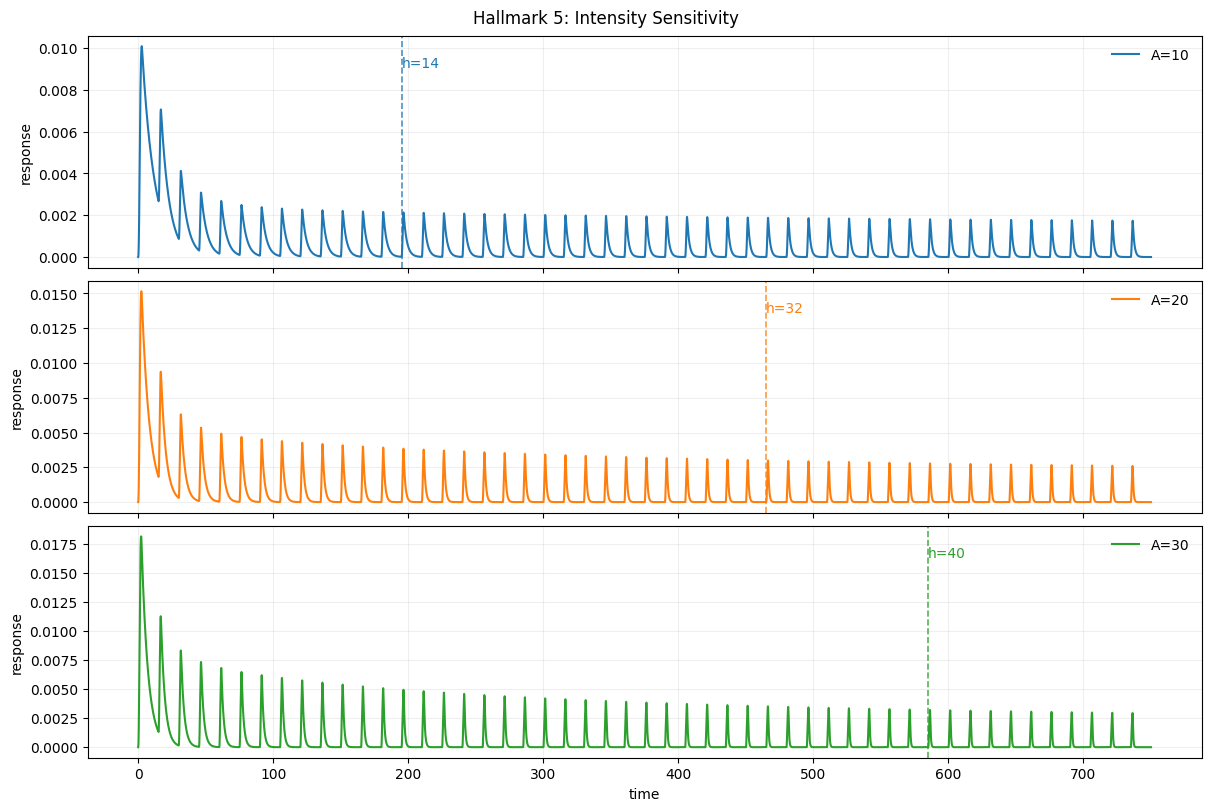

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for idx, (ax, run) in enumerate(zip(axes, h5_info['runs'])):
    color = colors[idx % len(colors)]
    A_run = run['A']
    h_run = h5_info['habituation_times'][idx]
    t = run['time']
    response = run['response']
    ht_time = (h_run - 1) * T

    ax.plot(t, response, color=color, label=f'A={A_run:g}')
    ax.axvline(ht_time, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
    ax.text(ht_time, 0.9 * np.max(response), f'h={int(h_run)}', color=color, ha='left')
    ax.set_ylabel('response')
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, loc='upper right')

axes[-1].set_xlabel('time')
fig.suptitle('Hallmark 5: Intensity Sensitivity')
plt.show()


## Hallmark 6


In [16]:
stricter_recovery_tolerance = 0.01
h6_loss, h6_info = hallmark6_loss(
    ciff, A, T, Ton, h1_info['habituation_time'], h2_info['recovery_time'], x0,
    stricter_recovery_tolerance=stricter_recovery_tolerance,
    max_gap=4000.0,
    search_depth=16,
    return_info=True,
)

print(f'Hallmark 6 subliminal accumulation term: {h6_loss}')
pd.DataFrame({
    'quantity': ['normal recovery time', 'stricter recovery time', 'ratio'],
    'value': [h6_info['recovery_time'], h6_info['stricter_recovery_time'], h6_loss],
})


Hallmark 6 subliminal accumulation term: 0.580872651167023


,quantity,value
0,normal recovery time,1558.471680
1,stricter recovery time,2682.983398
2,ratio,0.580873


## Visualize Hallmark 6


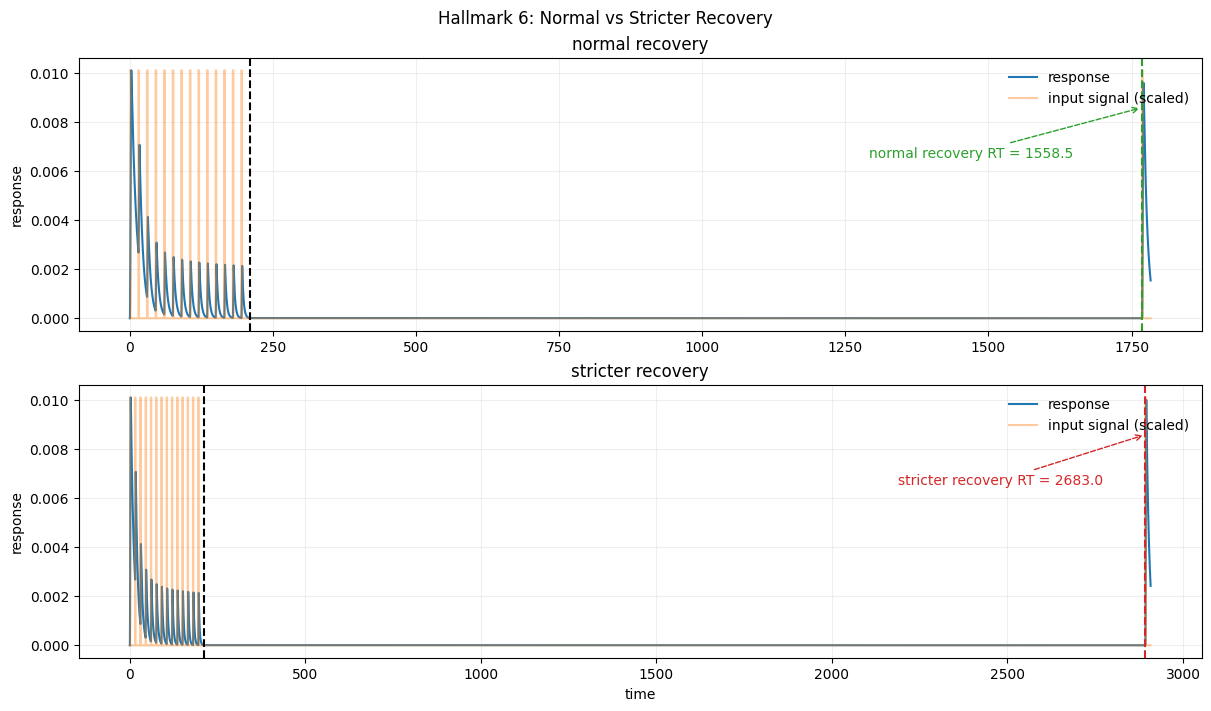

In [17]:
normal_t = h2_info['time']
normal_response = h2_info['response']
normal_input = h2_info['input_signal']
stricter_t = h6_info['time']
stricter_response = h6_info['response']
stricter_input = h6_info['input_signal']
normal_recovery_time = h6_info['recovery_time']
stricter_recovery_time = h6_info['stricter_recovery_time']
training_end = h1_info['habituation_time'] * T - 0.01

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False, constrained_layout=True)
plots = [
    (axes[0], normal_t, normal_response, normal_input, normal_recovery_time, 'C2', 'normal recovery'),
    (axes[1], stricter_t, stricter_response, stricter_input, stricter_recovery_time, 'C3', 'stricter recovery'),
]

for ax, t, response, input_signal, recovery_time, color, label in plots:
    recovery_end = training_end + recovery_time
    response_max = max(np.max(response), 1e-12)
    scaled_input = input_signal / max(np.max(input_signal), 1e-12) * response_max

    ax.plot(t, response, label='response', color='C0')
    ax.step(t, scaled_input, where='post', label='input signal (scaled)', color='C1', alpha=0.4)
    ax.axvline(training_end, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(recovery_end, color=color, linestyle='--', linewidth=1.5)
    ax.annotate(f'{label} RT = {recovery_time:.1f}', xy=(recovery_end, 0.85 * response_max),
                xytext=(recovery_end - 8 * T, 0.65 * response_max),
                arrowprops=dict(arrowstyle='->', linestyle='--', color=color),
                ha='right', color=color)
    ax.set_ylabel('response')
    ax.set_title(label)
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, loc='upper right')

axes[-1].set_xlabel('time')
fig.suptitle('Hallmark 6: Normal vs Stricter Recovery')
plt.show()


## Combined Hallmark Loss


In [18]:
ciff.reset()
combined_loss, combined_info = habituation_hallmarks_loss(
    ciff, A, T, Ton, n_pulses, x0,
    weights={
        'hallmark1': 1.0,
        'hallmark2': 1.0,
        'hallmark3': 1.0,
        'hallmark4': 1.0,
        'hallmark5': 1.0,
        'hallmark6': 1.0,
    },
    T_values=T_values,
    A_values=A_values,
    h1_kwargs={'tolerance': 0.01, 'eps': 1e-12, 'LARGE_NUMBER': 1e4},
    h2_kwargs={'recovery_tolerance': 0.05, 'max_gap': 4000.0, 'search_depth': 16},
    h3_kwargs={'n_series': 2, 'recovery_gap_fraction': 0.5, 'tolerance': 0.01},
    h4_kwargs={'tolerance': 0.01},
    h5_kwargs={'tolerance': 0.01},
    h6_kwargs={'stricter_recovery_tolerance': stricter_recovery_tolerance, 'max_gap': 4000.0, 'search_depth': 16},
    return_info=True,
)

print(f'Combined hallmark loss: {combined_loss}')
print('Stored reward:', ciff.last_task_info['reward'])
pd.DataFrame({
    'component': list(combined_info['component_losses'].keys()),
    'loss': list(combined_info['component_losses'].values()),
    'weight': [combined_info['component_weights'][name] for name in combined_info['component_losses']],
})


Combined hallmark loss: 2.3721907948091214
Stored reward: 2.3721907948091214


,component,loss,weight
0,hallmark1,0.024768,1.0
1,hallmark2,0.389618,1.0
2,hallmark3,0.000000,1.0
3,hallmark4,0.758182,1.0
4,hallmark5,0.618750,1.0
5,hallmark6,0.580873,1.0


## Render Combined Hallmarks


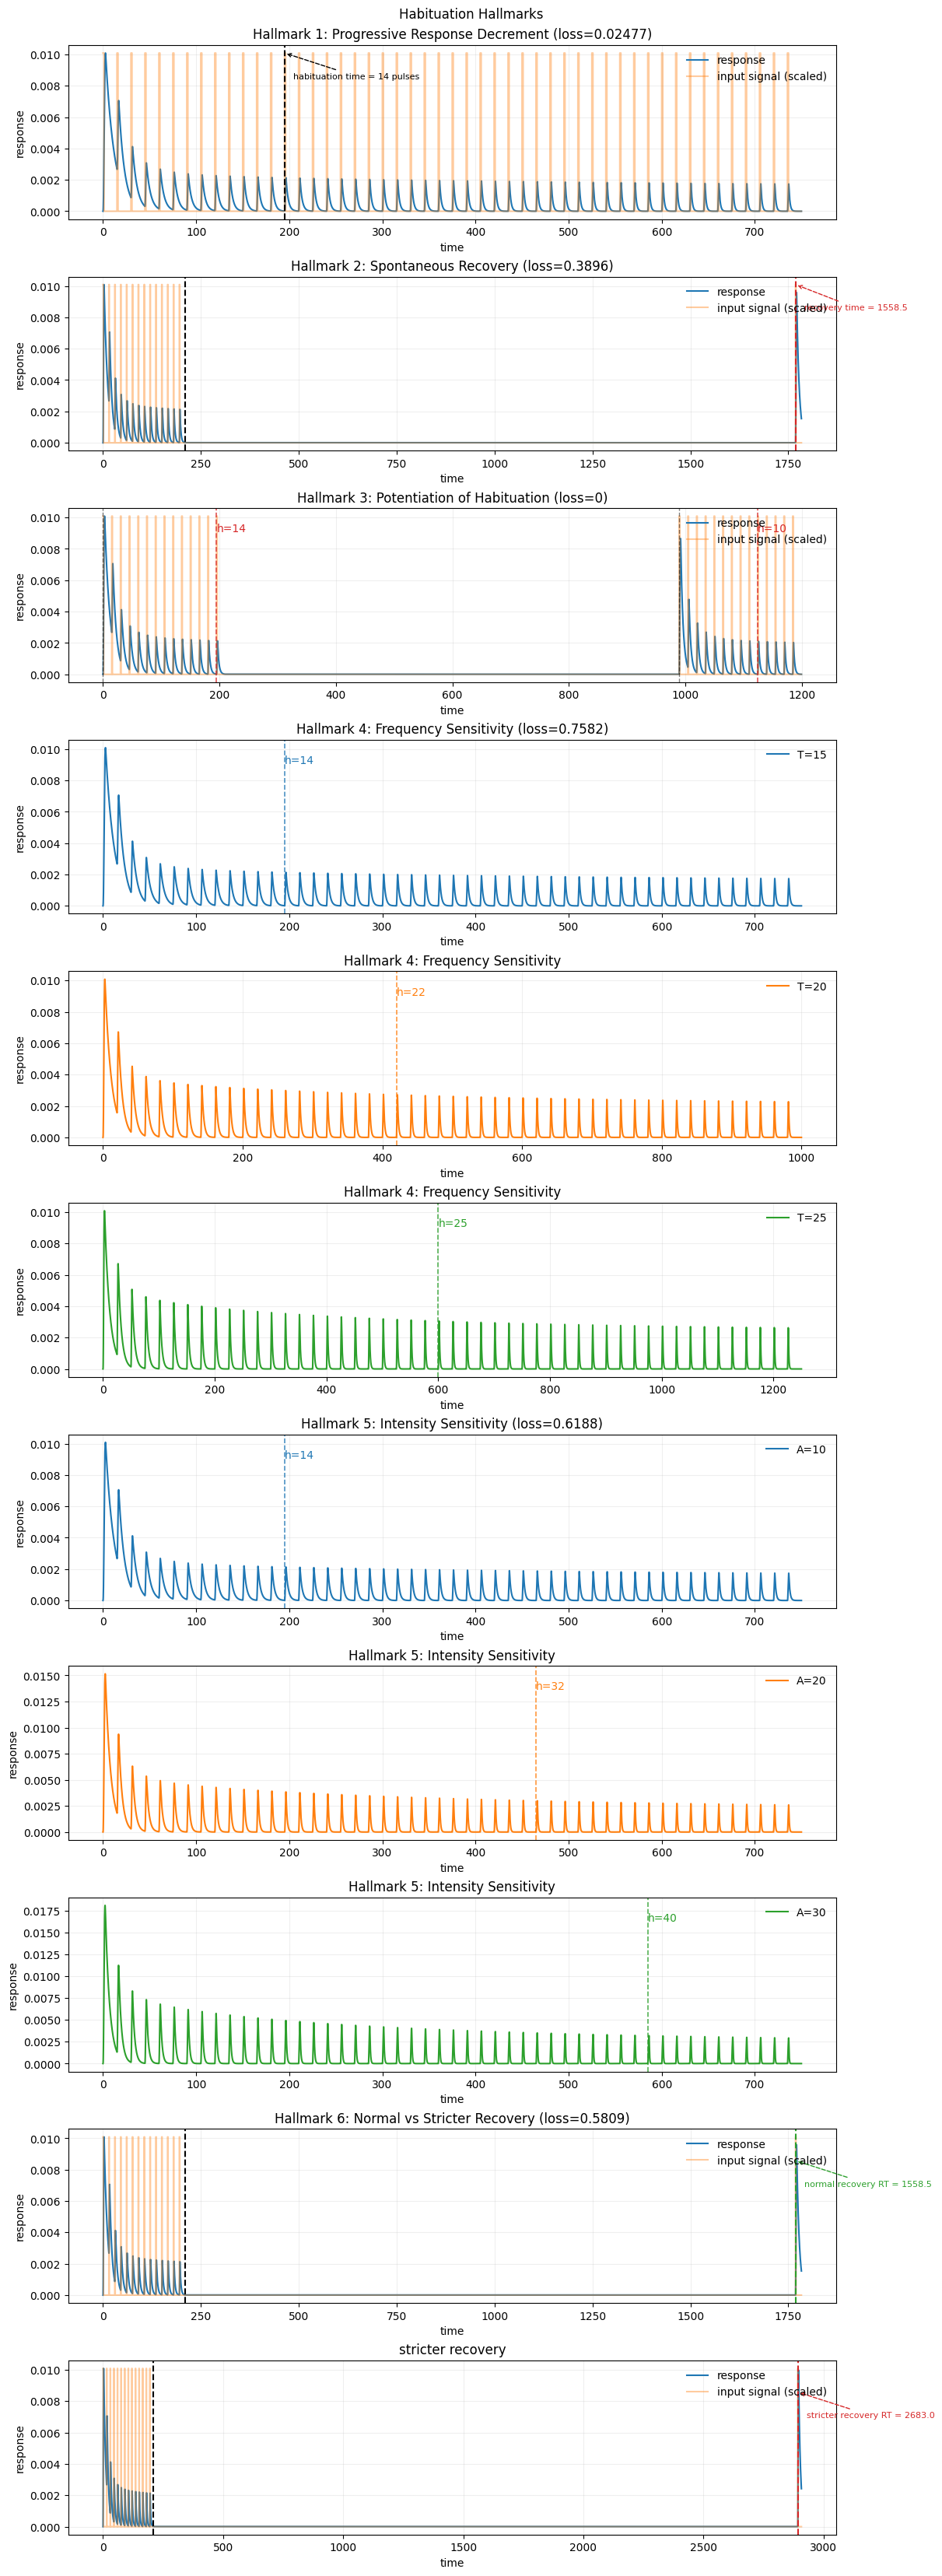

In [19]:
fig, axes = render_habituation(ciff)
plt.show()
